# **Install and Import Package**


In [ ]:
#Install required libraries (run only 1 time)
%pip install requests
%pip install matplotlib
%pip install statsmodels



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import requests
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sea



import re
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import  SentimentIntensityAnalyzer

#Initialise VADER sentiment analysis
sia = SentimentIntensityAnalyzer()


# **Step 1: Crawl a Real-World Dataset**

### 1. Data Collection

In this project, I collected data from public Reddit API using the 'requests' library in Python. The target dataset consists of the **top posts from r/apple community over the past year**, based on Reddit's own "top" listing.

**Data Source**

- Platform: Reddit
- Subreddit: 'r/apple'
- Endpoint: 'https://www.reddit.com/r/{subreddit}/{listing}.json'
- Access method: Public API (no authentication token, using USER-Agent)

**Scraping Strategy**

Reddit's API only returns a limited number of posts per request. To collect as much as possible, I used **pagination with thie 'after' token**:

1. Request Page 1 using '/top.json' with 't=year' and 'limit=250'.
2. Extract the last pot's 'kind' and 'id' to build an 'after' token.
3. Use the token to request **Page 2** (posts after the precious batch).
4. Repeat the process for **Page 3** to reach around 250 posts in total.
5. Combine all pages into single table dataframe.

**Variable collected**

For each Reddit post, I extracted:
- 'Title' : Post title text
- 'Upvotes' : Number of upvotes or like ('ups')
- 'Flair' : Post flair label (topic/category)
- 'Num_Comments': Number of comments
- 'Body' : Post self-text (for text posts)
- 'Created_UTC' : Post creation time in Unix timestamp
- 'Post_ID' : Unique Reddit post ID

These were stored in three intermediate Dataframes (top100', 'top200', 'top250'), which were then combine into a final dataset called 'top_reddit_posts'

The final dataset is also exported to CSV file types for later analysis: 'reddit_top_posts_year.csv'


In [3]:
#Step1: Ste up Reddit scraping parameters
subreddit = 'apple'
timeframe = 'year'   # hour, day, week, month, year, all
listing = 'top' # controversial, best, hot, new, random, rising, top
limit = 250    #posts per page 

In [4]:
def get_reddit(subreddit, listing, limit, timeframe):
    """
    Pull the first page of pots from subreddit using Reddit's public API.

    Parameters: 
        subreddit (str): Name of the subreddit 
        listing (str): Sorting post type 
        limit (int): Maximum number of posts to request
        timeframe (str): Time range for post 

    Returns: 
        Response object
    """
    try:
        base_url = (
            f'https://www.reddit.com/r/{subreddit}/{listing}.json'
            f'?limit={limit}&t={timeframe}'
        )
        request = requests.get(base_url, headers={'User-agent': 'SDPA'})
    except Exception as e:
        print('An Error Occurred in get_reddit:', e)
        return None
    return request


def get_reddit_after(subreddit, listing, limit, timeframe, after_token):
    """
    Get Reddit posts after a specific token (pagination)
    
    The 'after' token tells reddit where the previous page ended, 
    so we can request the next batch posts.

    Parameters: 
        subreddit (str): Subreddit name
        listing (str): Sorting type
        limit (int): Number of posts to request
        timeframe (str): Time range for listing post
        after_token (str): Token representing where to continue next post

    Returns: 
        Response object (or None if an error occurs)
    """
    try:
        base_url = (
            f'https://www.reddit.com/r/{subreddit}/{listing}.json'
            f'?limit={limit}&t={timeframe}&after={after_token}'
        )
        request = requests.get(base_url, headers={'User-agent': 'SDPA'})
    except Exception as e:
        print('An Error Occurred in get_reddit_after:', e)
        return None
    return request

In [5]:
# Page 1 
r = get_reddit(subreddit, listing, limit, timeframe)
data = json.loads(r.content)

temp = []
children = data['data']['children']
print('Page 1 posts:', len(children))

for i in range(len(children)):
    post = children[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top100 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

# Page 2  
after_token = data['data']['children'][len(children)-1]['kind'] + '_' + \
              data['data']['children'][len(children)-1]['data']['id']

r_new = get_reddit_after(subreddit, listing, limit, timeframe, after_token)
data_second = json.loads(r_new.content)

temp = []
children2 = data_second['data']['children']
print('Page 2 posts:', len(children2))

# Only take up to 100 posts from Page 2 to avoid reject from API 
for i in range(min(100, len(children2))):
    post = children2[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top200 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

#  Page 3 (Only 50 posts can be pulled)
after_token_second = children2[len(children2)-1]['kind'] + '_' + \
                     children2[len(children2)-1]['data']['id']

r_new2 = get_reddit_after(subreddit, listing, limit, timeframe, after_token_second)
data_third = json.loads(r_new2.content)

temp = []
children3 = data_third['data']['children']
print('Page 3 posts:', len(children3))

for i in range(len(children3)):
    post = children3[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top250 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

# Combine all into one dataset 
top_reddit_posts = pd.concat([top100, top200, top250], ignore_index=True)

# Ensure numeric columns are of correct type
top_reddit_posts['Upvotes'] = pd.to_numeric(top_reddit_posts['Upvotes'])
top_reddit_posts['Num_Comments'] = pd.to_numeric(top_reddit_posts['Num_Comments'])

print('Final combined shape:', top_reddit_posts.shape)

#Save to CSV 
top_reddit_posts.to_csv('reddit_top_posts_year.csv', index=False)
top_reddit_posts

Page 1 posts: 100
Page 2 posts: 100
Page 3 posts: 49
Final combined shape: (249, 7)


,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13574,iPhone,1362,,1743785410.0,1jrgmvl
1,Most iPhone owners see little to no value in A...,11258,Apple Intelligence,1431,,1734363217.0,1hflpje
2,Apple shareholders say no to scrapping company...,9867,Discussion,701,,1740503162.0,1ixzyrj
3,Apple sued for false advertising over Apple In...,8766,Apple Intelligence,610,,1742509626.0,1jg1k6j
4,Apple is racing to fly planes of iPhones into ...,7790,iPhone,550,,1744054856.0,1jtu9k4
...,...,...,...,...,...,...,...
244,An update on Blood Oxygen for Apple Watch in t...,1471,Apple Newsroom,281,,1755179314.0,1mq172h
245,iPhone 17 Air Launching Later This Year With T...,1474,iPhone,461,,1745508497.0,1k6v2ir
246,Apple considers expanding iPhone assembly in B...,1466,iPhone,567,,1743851599.0,1js144l
247,Introducing iPhone Pocket: a beautiful way to ...,1460,iPhone,1409,,1762852511.0,1ou4vur


# **Step 2: Perform data preparation and cleaning**

## 2.1 Add features column and Enrich Data

### 2.1.1 Convert Unix Timestamp to Real Date

Reddit has provided the post creation time in UNIX timestamp format, which is the number of seconds since 1 January 1970. 
To analyze trends over time (daily posting patterns, upvotes over time, etc.) we must convert this into human-readable datetime format.

In [6]:
#Convert UNIX Timestamp into Real Date
top_reddit_posts['Created_At'] = pd.to_datetime(top_reddit_posts['Created_UTC'], unit='s')

After converting to datetime, we extract:
- Date only: for grouping by day/month
- Time only: for identify post patterns (peak hours)

In [7]:
# Convert full timestamp into date column

# Extract calendar date (YYYY-MM-DD)
top_reddit_posts['Created_Date'] = top_reddit_posts['Created_At'].dt.date #Extract calendar date

#Extract the time of day (HH:MM:SS)
top_reddit_posts['Created_Time'] = top_reddit_posts['Created_At'].dt.time #Extract Time 

In [8]:
top_reddit_posts

,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Created_Date,Created_Time
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13574,iPhone,1362,,1743785410.0,1jrgmvl,2025-04-04 16:50:10,2025-04-04,16:50:10
1,Most iPhone owners see little to no value in A...,11258,Apple Intelligence,1431,,1734363217.0,1hflpje,2024-12-16 15:33:37,2024-12-16,15:33:37
2,Apple shareholders say no to scrapping company...,9867,Discussion,701,,1740503162.0,1ixzyrj,2025-02-25 17:06:02,2025-02-25,17:06:02
3,Apple sued for false advertising over Apple In...,8766,Apple Intelligence,610,,1742509626.0,1jg1k6j,2025-03-20 22:27:06,2025-03-20,22:27:06
4,Apple is racing to fly planes of iPhones into ...,7790,iPhone,550,,1744054856.0,1jtu9k4,2025-04-07 19:40:56,2025-04-07,19:40:56
...,...,...,...,...,...,...,...,...,...,...
244,An update on Blood Oxygen for Apple Watch in t...,1471,Apple Newsroom,281,,1755179314.0,1mq172h,2025-08-14 13:48:34,2025-08-14,13:48:34
245,iPhone 17 Air Launching Later This Year With T...,1474,iPhone,461,,1745508497.0,1k6v2ir,2025-04-24 15:28:17,2025-04-24,15:28:17
246,Apple considers expanding iPhone assembly in B...,1466,iPhone,567,,1743851599.0,1js144l,2025-04-05 11:13:19,2025-04-05,11:13:19
247,Introducing iPhone Pocket: a beautiful way to ...,1460,iPhone,1409,,1762852511.0,1ou4vur,2025-11-11 09:15:11,2025-11-11,09:15:11


### 2.1.2 Add Setimental Analysis Features

**VADER (Valence Aware Dictionary and sEntiment Reasoner)** is a rule based sentiment analysis tool specifically designed for social media text such as Reddit and Twitter which was created by C.J. Hutto and Eric Gilbert in 2014.

**VADER** comes pre-built with
- A lexicon of more than 7500 words rated for positive, neutral and negative emotional intensiy
- Built-in handlng of social media behaviour

This section we
1. Remove old sentiment columns to avoid bug (duplication) when the code is rerun 
2. Apply VADER to compute: 
   1. Title_compound --> continuous sentiment score
   2. Title_Sent --> categorical Positive/Neutral/Negative

These will be used for: 
- sentiment distribution analysis
- correlation
- hypothesis test


To understand the tone of each Reddit post, I applied VADER (Valence Aware Dictionay and sEntiment Reasoner) which is a rule based sentiment model designed specifically for social media text. 

VADER returns values as 
1. pos : proportion of positive sentiment which compound score > 0.05
2. neu : proportion of neutral snetiment which compound score = 0
3. neg : proporition of negative sentiment which compound score < -0.05

In [9]:
 # Remove ALL old VADER columns if they exist (In case rerun the code)
cols_to_remove = [
    'Title_compound', 'Title_Sent',
    'title_neg', 'title_neu', 'title_pos', 
    'title_compound'
]

top_reddit_posts.drop(
    columns=[c for c in cols_to_remove if c in top_reddit_posts.columns],
    inplace=True
)

# calculate new sentiment by apply VADER sentiment analysis on post titles
results = []

for headline in top_reddit_posts['Title']:
    sentiment = sia.polarity_scores(headline)
    compound = sentiment['compound']

    if compound >= 0.05:
        sentiment_class = 'Positive'
    elif compound <= -0.05:
        sentiment_class = 'Negative'
    else:
        sentiment_class = 'Neutral'
    
    results.append({
        'Title_compound': compound,
        'Title_Sent': sentiment_class
    })

#Convert to Dataframe and attach to main table
sentimental_title = pd.DataFrame(results)
top_reddit_posts = pd.concat([top_reddit_posts, sentimental_title], axis=1)

# Ensure compound is numeric
top_reddit_posts['Title_compound'] = pd.to_numeric(top_reddit_posts['Title_compound'])


sentimental_title

,Title_compound,Title_Sent
0,0.0000,Neutral
1,0.5130,Positive
2,-0.2960,Negative
3,0.4767,Positive
4,0.0000,Neutral
...,...,...
244,0.0000,Neutral
245,0.0000,Neutral
246,0.0000,Neutral
247,0.5994,Positive


### 2.1.3 Add Word Count Features

This section to understand text patterns and their relationships with engagement, we compute: 
- Title Word Count
- Body Word Count

These are important for:
- Checking if longer posts receive more engagement 
- Understanding writing style differences between flairs
- Use regression/ modeling later

In [10]:
# Title Word Count
top_reddit_posts['Title_Word_Count'] = top_reddit_posts['Title'].astype(str).str.split().str.len()

# Body Word Count
top_reddit_posts['Body_Word_Count'] = top_reddit_posts['Body'].astype(str).str.split().str.len()

## 2.2 Handle Data

### 2.2.1 Handle Missing Data

Handle missing data by replace:
- Missing Flair: "None"
- Missing Body: Empty string

This avoids errors in analysis and prevents NaNs from contaminating plots or calcualtions

In [11]:
top_reddit_posts['Flair'] = top_reddit_posts['Flair'].fillna('None')
top_reddit_posts['Body'] = top_reddit_posts['Body'].fillna('')
top_reddit_posts


,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Created_Date,Created_Time,Title_compound,Title_Sent,Title_Word_Count,Body_Word_Count
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13574,iPhone,1362,,1743785410.0,1jrgmvl,2025-04-04 16:50:10,2025-04-04,16:50:10,0.0000,Neutral,14,0
1,Most iPhone owners see little to no value in A...,11258,Apple Intelligence,1431,,1734363217.0,1hflpje,2024-12-16 15:33:37,2024-12-16,15:33:37,0.5130,Positive,13,0
2,Apple shareholders say no to scrapping company...,9867,Discussion,701,,1740503162.0,1ixzyrj,2025-02-25 17:06:02,2025-02-25,17:06:02,-0.2960,Negative,9,0
3,Apple sued for false advertising over Apple In...,8766,Apple Intelligence,610,,1742509626.0,1jg1k6j,2025-03-20 22:27:06,2025-03-20,22:27:06,0.4767,Positive,8,0
4,Apple is racing to fly planes of iPhones into ...,7790,iPhone,550,,1744054856.0,1jtu9k4,2025-04-07 19:40:56,2025-04-07,19:40:56,0.0000,Neutral,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,An update on Blood Oxygen for Apple Watch in t...,1471,Apple Newsroom,281,,1755179314.0,1mq172h,2025-08-14 13:48:34,2025-08-14,13:48:34,0.0000,Neutral,11,0
245,iPhone 17 Air Launching Later This Year With T...,1474,iPhone,461,,1745508497.0,1k6v2ir,2025-04-24 15:28:17,2025-04-24,15:28:17,0.0000,Neutral,12,0
246,Apple considers expanding iPhone assembly in B...,1466,iPhone,567,,1743851599.0,1js144l,2025-04-05 11:13:19,2025-04-05,11:13:19,0.0000,Neutral,12,0
247,Introducing iPhone Pocket: a beautiful way to ...,1460,iPhone,1409,,1762852511.0,1ou4vur,2025-11-11 09:15:11,2025-11-11,09:15:11,0.5994,Positive,11,0


### 2.2.2 Identify & Handle Outliers

#### 2.2.2.1 Check for Skewness

**Check for Skewness** which tell us if a feature is:
- Symmetric
- Moderately skewed
- Highly skewed

This helps decide if we need outlier handling or not

We check skewness for: 
- Upvotes
- Num_Comments
- Title_compound
- Title_Word_Count
- Body_Word_Count

In [12]:
cols = ['Upvotes', 'Num_Comments', 'Title_compound', 'Title_Word_Count', 'Body_Word_Count']

for col in cols:
    skew_value = top_reddit_posts[col].skew()

    # Interpretation rule
    if abs(skew_value) > 1:
        interpretation = 'Highly skewed'
    elif abs(skew_value) > 0.5:
        interpretation = 'Moderately skewed'
    else:
        interpretation = 'Approximately symmetric'
    
    print(f'{col}: {skew_value:.4f} --> {interpretation}')

Upvotes: 3.3271 --> Highly skewed
Num_Comments: 2.5861 --> Highly skewed
Title_compound: -0.1223 --> Approximately symmetric
Title_Word_Count: 3.0883 --> Highly skewed
Body_Word_Count: 7.5216 --> Highly skewed


**Distribution Characteristics of the Dataset**

After calculating skewness of numeric variables, we can observed that **most engagement-related and length-related features are highly skewed**

- **Upvotes (Skew = 3.3624)**
  This indicates long right tail, this shows that a few posts receive extremely high upvotes, while most receive relatively low numbers, which is normal for social media platforms where only handful of posts can go viral. 

- **Number of Comments (Skew = 2.5861)**
  A small number of posts attract disproportionate attention, leading to heavily skewed distribution. 

- **Title Sentiment Compound Score (Skew = -0.1212)**
  This value is close to zero which show that it roughly symmetric.

- **Title Word Count (Skew = 3.0856)**
  This shows that most titles are short, leading to shrong right skew.

- **Body Word Count (Skew = 7.5258)**
  This value show an extremely skewed because many posts have no body text, while few contain long paragraphs.

Therefore, **engagement and text-length variables are dominated by a few extreme posts**, while most items remain low. 

#### 2.2.2.2 Log transformation 
**Use Log-Transform on the highly skewed features**

Highly skewed data may distort regression and hypothesis tests. 

To reduce skewness, we apply log1p() to:
- Upvotes
- Num_Comments
- Body_Word_Count

(Title_compound does not need log)

In [13]:
top_reddit_posts['Log_Upvotes'] = np.log1p(top_reddit_posts['Upvotes'])
top_reddit_posts['Log_Num_Comments'] = np.log1p(top_reddit_posts['Num_Comments'])
top_reddit_posts['Log_Body_Word_Count'] = np.log1p(top_reddit_posts['Body_Word_Count'])

#### 2.2.2.3 Rechecking Skewness after transformation

In [14]:
cols = ['Log_Upvotes', 'Log_Num_Comments', 'Title_compound', 'Title_Word_Count', 'Log_Body_Word_Count']

for col in cols:
    skew_value = top_reddit_posts[col].skew()

    # Interpretation rule
    if abs(skew_value) > 1:
        interpretation = 'Highly skewed'
    elif abs(skew_value) > 0.5:
        interpretation = 'Moderately skewed'
    else:
        interpretation = 'Approximately symmetric'
    
    print(f'{col}: {skew_value:.4f} --> {interpretation}')

Log_Upvotes: 1.4825 --> Highly skewed
Log_Num_Comments: -1.9729 --> Highly skewed
Title_compound: -0.1223 --> Approximately symmetric
Title_Word_Count: 3.0883 --> Highly skewed
Log_Body_Word_Count: 3.2251 --> Highly skewed


Log transformation was used to reduce the impact of extreme values in Upvotes, Comments and Word Counts. After applying, you can see the skewness level decreased. Overall , its improve:
1. normality of data
2. stability for correlation and regression analysis 
3. reduced influence of outliers

However, data may not be symmetric as it is a social media platform that can make the outliers can appear. The transformed variables are now more suitable for testing and modeling.

# **Step 3: Perform exploratory analysis** 

In this section, I explore the Reddit dataset to understand the ditribution of numerical variables, posting behaviour across flair categories, common word patterns, and sentiment patterns. 

## 3.1 Statistic Descriptive

The table provides descriptive statistics (mean, min, max, quartiles, standard deviation) for the main numerical variables such as Upvotes, Number of Comments, sentiment compound score, and word counts. 

In [15]:
numeric_cols = ['Upvotes','Num_Comments', 'Title_compound', 'Title_Word_Count', 'Body_Word_Count']
top_reddit_posts[numeric_cols].describe()

,Upvotes,Num_Comments,Title_compound,Title_Word_Count,Body_Word_Count
count,249.000000,249.000000,249.000000,249.000000,249.000000
mean,2591.831325,478.132530,0.031403,12.140562,7.863454
std,1595.440814,352.030336,0.297530,5.671832,40.433007
min,1460.000000,0.000000,-0.790600,2.000000,0.000000
25%,1670.000000,251.000000,0.000000,9.000000,0.000000
50%,2093.000000,372.000000,0.000000,11.000000,0.000000
75%,2768.000000,610.000000,0.177900,13.000000,0.000000
max,13574.000000,2927.000000,0.784500,50.000000,413.000000


The numerical summary statistics provide an initial understanding of the distribution and scale of the key variables in the dataset. *Upvotes* range widely from **1,462 to 13,574** showing variation in how much engagment Reddit posts receive. The mean of upvote is much higher than median **(2,577 > 2,071)** which indicate right skewed distribution, where a small number of highly upvoted posts pull average upward. A similar pattern also appears in *Num_Comments*, with values from **0 to 2,927** and also mean of 475 which also show only few highly discussed posts.

The *Sentiment Compound* for title also scores range from **-0.79 to 0.78** which is interesting as it cover full negative to positive sentiment spectrum. However, both mean **(0.03)** and median **(0.00)** show that most titles tend to be neutral.

*Title_Word_Count* averages is around **12 words**, with most titles being short and concise, and also max of **50 words**. On the other hand, *Body_Word_Count* shows extremely high variability. The median is **0**, meaning that more than half of the posts contain **no body text**, while few long posts can reach up to **413 words**, which show highly skewed distribution. 

##  **3.2 Flair Analysis**

### **3.2.1 Flair Distribution Pie Chart**

This table shows how many posts belong to each flair label as originally scraped.

In [16]:
top_reddit_posts.groupby('Flair').count()   

,Title,Upvotes,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Created_Date,Created_Time,Title_compound,Title_Sent,Title_Word_Count,Body_Word_Count,Log_Upvotes,Log_Num_Comments,Log_Body_Word_Count
Flair,,,,,,,,,,,,,,,,
AirPods,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
App Store,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6
Apple Card,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Intelligence,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22
Apple Music,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple News+,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Newsroom,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
Apple Pay,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Retail,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


Many flair labels are inconsisten (space dif, uncommon categories) 
This step cleans the flair values, group rare categories as "Other" and creates Pie Chart to show distribution of **Apple** subreddit topics.

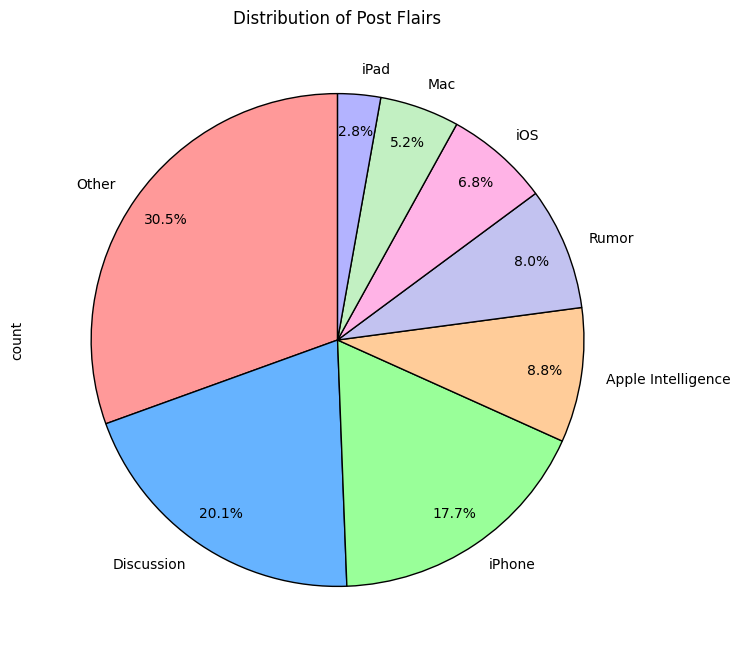

In [17]:
exclude_flair_none = top_reddit_posts[top_reddit_posts['Flair'] != 'None'].copy()

# Normalise text: remove spaces and standardise case (As some of flair have spacebar)
exclude_flair_none['Flair'] = exclude_flair_none['Flair'].str.strip()

main_flairs = [
    'iPhone',
    'Discussion',
    'iOS',
    'Mac',
    'Rumor',
    'iPad',
    'Apple Intelligence'
]

# Clean flairs
top_reddit_posts['Flair_Clean'] = exclude_flair_none['Flair'].copy()
top_reddit_posts['Flair_Clean'] = top_reddit_posts['Flair_Clean'].where(top_reddit_posts['Flair_Clean'].isin(main_flairs), other='Other')
top_reddit_posts = top_reddit_posts.copy()

# Count categories
count_flair = top_reddit_posts['Flair_Clean'].value_counts()

# Custom color palette (8 colors) 
colors = [
    '#ff9999', '#66b3ff', '#99ff99', '#ffcc99',
    '#c2c2f0', '#ffb3e6', '#c2f0c2', '#b3b3ff',
]

# Plot 
plt.figure(figsize=(11,8))
count_flair.plot(
    kind='pie',
    colors=colors[:len(count_flair)],  # Use only the number of categories
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops={'edgecolor':'black'}
)

plt.title('Distribution of Post Flairs')
plt.show()

The pie chart shows which topic has been talkign about in the **Apple** subreddit. 

The largest porition of posts (30.4%) falls under the **"Other"** category which shows a wide range of miscellaneous topic that do not fit with predefined flair. Next are **Discussion (20.0%)** and **iPhone(17.6%)** which suggest that people in comunity often engage in general conversations or share information and news related to iPhone. Thirdly, **Apple Intelligence (8.8%)** have been show as notable categories as it had been introduced on **10 June 2024** at Worldwide Developers Conference (WWDC) which have show active interest of users in related topic about new software updates and news. **Rumor (8.0%)** and **iOS (7.2%)** also notable as it also show that people interest in speculative news and software updates for Apple products. However, **Mac (5.2%)** and **iPad (2.8%)** appears less in the top posts. 

### **3.2.2 Upvotes by Flair**

To understnad which topics receive the highest engagement, we also compute the average number of upvotes for each flair category. 

This bar chart shows which topics the community finds more interesting according to Upvotes

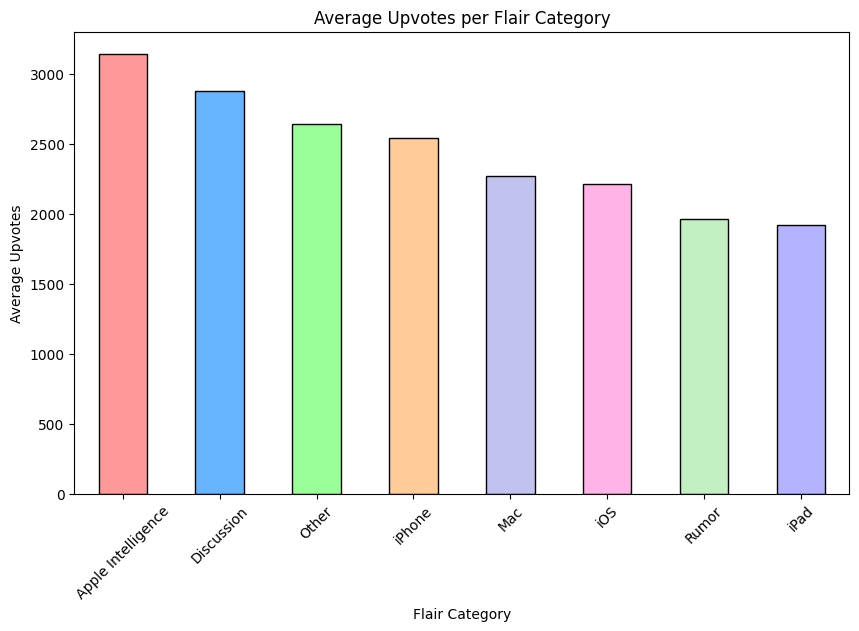

In [18]:
# Upvotes by Flair
Upvotes_By_Flair = top_reddit_posts.groupby('Flair_Clean')['Upvotes'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
colors = [
	'#ff9999',
    '#66b3ff', 
    '#99ff99', 
    '#ffcc99',
	'#c2c2f0', 
    '#ffb3e6', 
    '#c2f0c2', 
    '#b3b3ff',
]
Upvotes_By_Flair.plot(kind='bar', color=colors, edgecolor='black')

plt.title('Average Upvotes per Flair Category')
plt.xlabel('Flair Category')
plt.ylabel('Average Upvotes')
plt.xticks(rotation=45)
plt.show()

The bar chart illustrates how engagment, measured by the average number of upvotes that show across different flair categories in the r/Apple subreddit. The "Apple INtelligence" flair stands out as the most highly upvoted category with average over 3,100 upvotes. This shows that posts related to Apple's new AI features that just have been introduced generate the strongest community interest.

"Discussion" posts follow as the second-highest category, indicating that broad, conversational topics still attract strong engagement. Categories such as "Other", "iPhone", and "Mac" receive moderate upvotes which shows about less intense user interest in these theme topic. FInally, "Rumor" and "iPad" posts receive fewest upvotes, which may show that speculative content and iPad are less engage.

Overall, plot highlights that not all topics generate equal interest. This plot show about what have people interest throughout the year.

### 3.2.3 Number of Comments by Flair

This section looks at community discussio about how many comments in each category that can show debate and questions topics

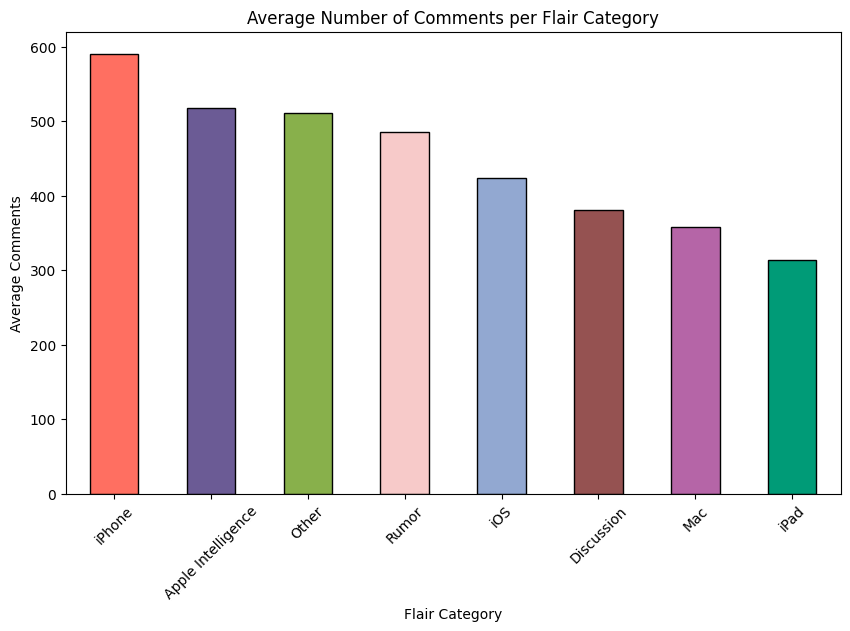

In [19]:
comments_by_flair = top_reddit_posts.groupby('Flair_Clean')['Num_Comments'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
colors = [
    '#FF6F61',  
    '#6B5B95',  
    '#88B04B',  
    '#F7CAC9',  
    '#92A8D1',  
    '#955251',  
    '#B565A7',  
    '#009B77'   
]
comments_by_flair.plot(kind='bar', color= colors, edgecolor='black')

plt.title('Average Number of Comments per Flair Category')
plt.xlabel('Flair Category')
plt.ylabel('Average Comments')
plt.xticks(rotation=45)
plt.show()

The bar chart above show the **average number of comments** received by Reddit posts across different *Flair_Clean* categories in the r/Apple subreddit. 

1. iPhone
    - iPhone posts receive highest amount average comments 
    - This shows that iPhone related content show strong community engagement which is normal as iPhone is the main product of Apple 

2. Apple Intelligence and "Other" 
    - Post under **Apple Intelligence** and **Other** attract discussion
    - Apple Intelligence have been topic that make users actively discussing due to new features and still not fully launched
    - While "Other" also include other topic which can lead to high engagment as it combine every other category
  
3. Rumor 
    - Rumor related contents can generate curiosity and debatable topic which lead to lively discussion post, this match to the bar chart

4. Discussion , Mac , iOS, iPad
    - These categories receive fewer comments but not significantly compare to other as these may show information with less need conversation.
    - Dicussion category shows some interest fact regarding about that it have fewer engagmenet comments than other as in discussion category

## 3.3 Text Analysis

### 3.3.1 Frequent Word Uses Chart

To understand what people talk about most in r/Apple, firstly tokenise all post titles into individual words. I remove standard **English** stopwords such as **The** , **Is**, **Are**, **He** as well as custom words that are not informative in this context such as **says**, **reddit**. I then count how often each word appears across all titles and plot the 15 most frequent words.

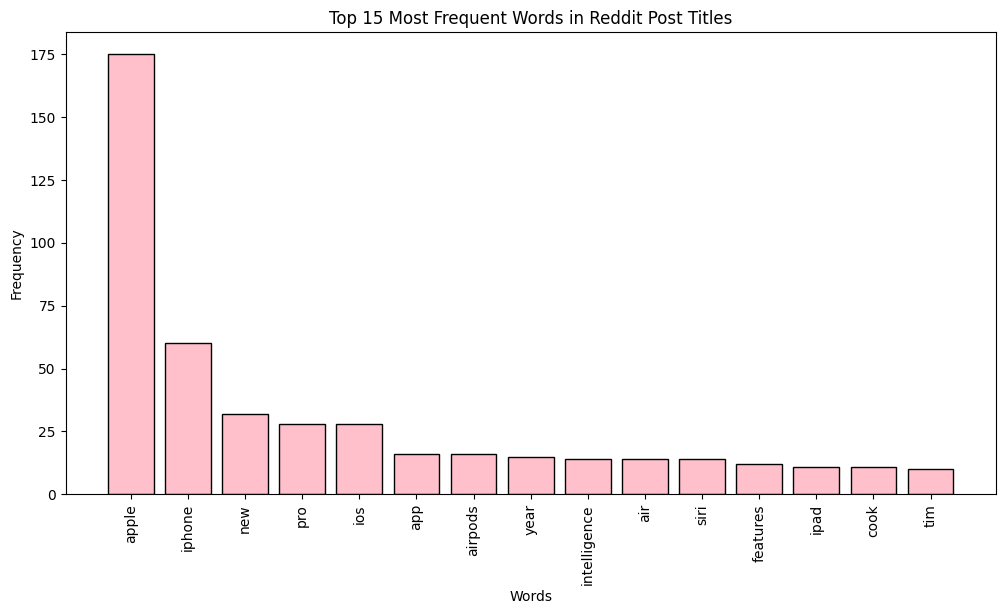

In [20]:
#  Base English stopwords (Ex. I, You, Is)
stop_words = set(stopwords.words('english'))

#  Add custom unwanted words 
custom_stopwords = {
    'says','reddit'
    }

# Merge them together
stop_words.update(custom_stopwords)

# Clean and extract words from titles 
title_clean = top_reddit_posts['Title'].astype(str).str.lower()

words = [] 

for t in title_clean:
    #Keep only alphabetic
    tokens = re.findall(r'\b[a-zA-Z]{3,}\b', t)
    #Remove stopwords
    tokens = [w for w in tokens if w not in stop_words]
    for w in set(tokens):   # unique per title
        words.append(w)

# Count word frequency
word_counts = Counter(words)

# Top 15 most frequent words
top_words = word_counts.most_common(15)


# Plot
plt.figure(figsize=(12, 6))
labels, counts = zip(*top_words)
plt.bar(labels, counts, 
        color= 'pink',
        edgecolor= 'black')
plt.xticks(rotation=90)
plt.title('Top 15 Most Frequent Words in Reddit Post Titles')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

The bar chart shows the most common used words in the titles of top posts from r/Apple subreddit. "**apple"** appears overwhelmingly more frequently than any other word which is unsurprisingly. The next common word is **"iphone"**, which show strong interest in Apple main product device. 

The other frequent words shows the users often discuss software updates, product release, models. However, there are two words that are notable and pop up which as **"Siri"** and **"Cook"** suggest interest in AI improvement of apple (siri) and how users interest in executive decisions and news from the word "cook" from **CEO Tim Cook**.

### 3.3.2 Frequent Bigram Word (2-Word Combos)

This section I also loot at bigram which is 2 word combination such as **apple watch** or **iphone 16**, by reuse the same cleaned tokens, build unique bigrams per title, and count how often each bigram appears.

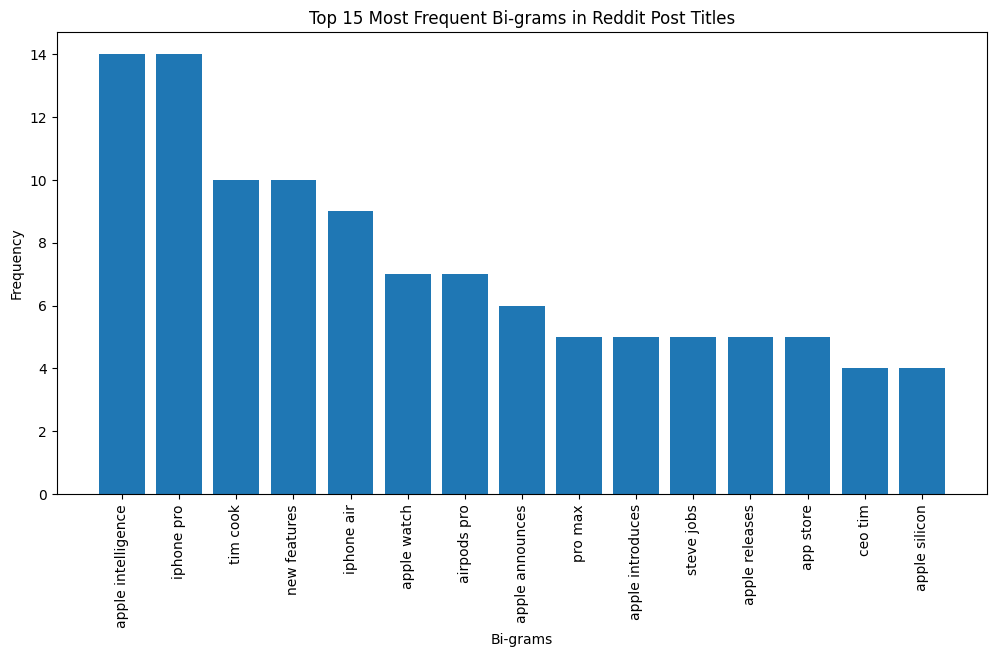

In [21]:
from nltk.util import ngrams

bigram_list = []

for t in title_clean:
    #Same tokenise as the single word analysis
    tokens = re.findall(r'\b[a-zA-Z]{3,}\b', t)
    tokens = [w for w in tokens if w not in stop_words]

    #Avoid over-counting within one post
    bigrams_in_title = set(ngrams(tokens, 2))
    
    for bg in bigrams_in_title:
        bigram_list.append(bg)

# Count bi-gram frequency
bigram_counts = Counter(bigram_list)

# Top 15 bi-grams
top_bigrams = bigram_counts.most_common(15)

# Prepare labels
labels, counts = zip(*top_bigrams)
labels = [' '.join(bg) for bg in labels]  # ('apple','watch') -> 'apple watch'

# Plot
plt.figure(figsize=(12, 6))
plt.bar(labels, counts)
plt.xticks(rotation=90)
plt.title('Top 15 Most Frequent Bi-grams in Reddit Post Titles')
plt.xlabel('Bi-grams')
plt.ylabel('Frequency')
plt.show()

The bigram analysis shows two word phrases appear most often in Apple subreddit post titles. **"Apple intellignece** and **"iphone pro"** are the top bigrams which shows interest in Apple AI features and premium iPohne models similar to other analysis. Other such as **"time cook", "new features", "iphone air" and "apple watch"** shows interest in ceo, software and hardware release and updates. 

### 3.3.3 Average Title Length Per Flair

I examine how lomng titles are in general by compure summary statstics for "Title_word_Count" that shows most titles are shorts. 

Then group by 'Flair_Clean' and calculate the average title word count per category. 

In [22]:
#Overall descriptive stats for title length
top_reddit_posts['Title_Word_Count'].describe()

count    249.000000
mean      12.140562
std        5.671832
min        2.000000
25%        9.000000
50%       11.000000
75%       13.000000
max       50.000000
Name: Title_Word_Count, dtype: float64

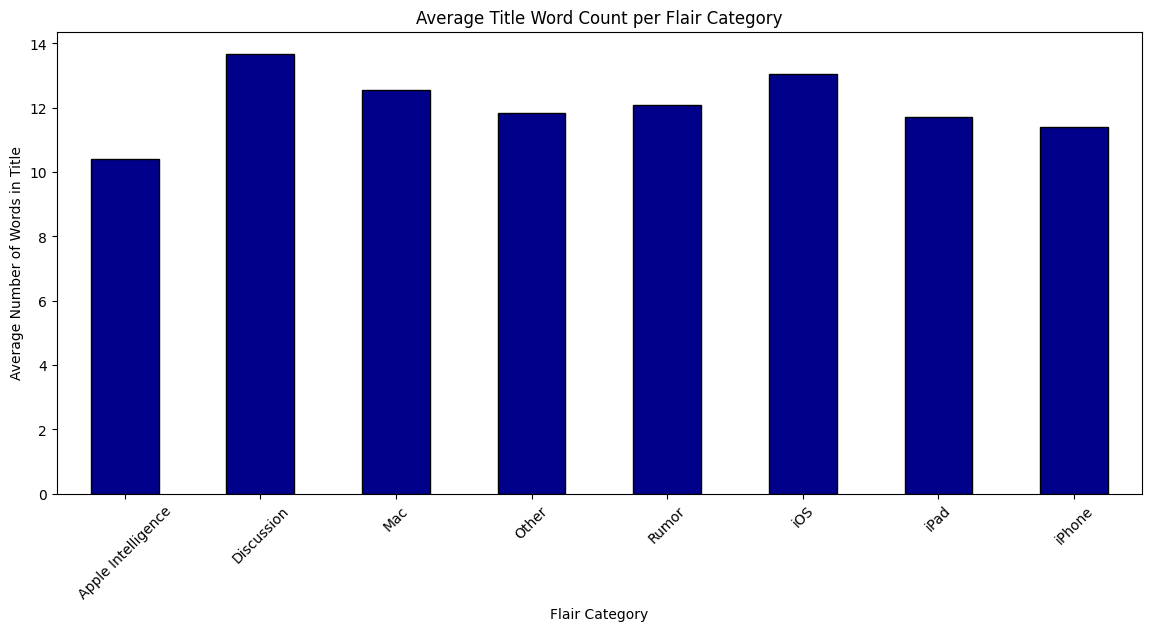

In [23]:
#Average title length per cleaned category
avg_title_length = top_reddit_posts.groupby('Flair_Clean')['Title_Word_Count'].mean()

plt.figure(figsize=(14,6))
avg_title_length.plot(kind='bar', color='darkblue', edgecolor='black')

plt.title('Average Title Word Count per Flair Category')
plt.xlabel('Flair Category')
plt.ylabel('Average Number of Words in Title')
plt.xticks(rotation=45)
plt.show()

This bar chart examines whether posts from different flair categories tend to use longer or shorter titles. 

Oveall the length is quite consisten across flair by around **10 to 14 words**

## 3.4 Sentimental Analysis 

### 3.4.1 Sentimental Analysis Distribution

Using VADER, each title is classified as Positive, Neutral or Negative based on
its compound sentiment score. I count how many posts fall into each sentiment class and visualise it with a donut-style pie chart.

This chart summarises the emotional tone of r/apple’s top posts over the year.


In [24]:
top_reddit_posts['Title_Sent'].value_counts()

Title_Sent
Neutral     124
Positive     71
Negative     54
Name: count, dtype: int64

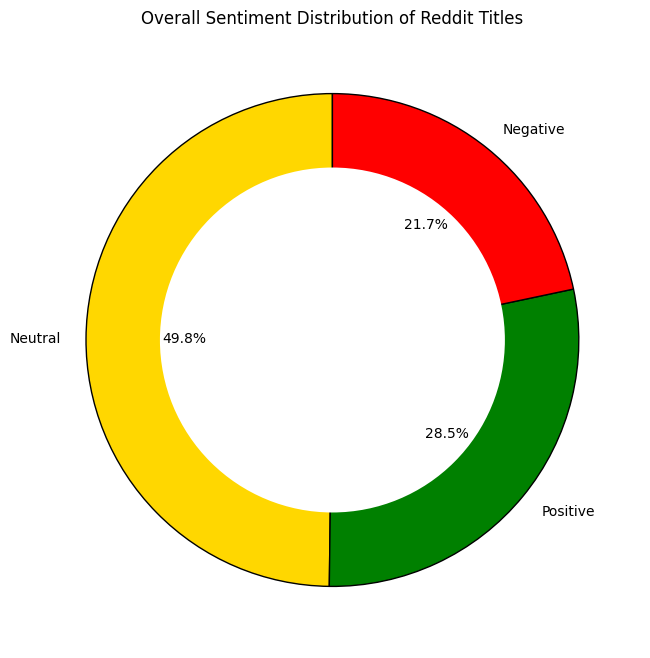

In [25]:
sentiment_counts = top_reddit_posts['Title_Sent'].value_counts()

# Colors (match your other charts)
colors = ['gold', 'green', 'red']  

plt.figure(figsize=(8,8))

# Pie chart
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Overall Sentiment Distribution of Reddit Titles')
plt.show()

The donut chart shows that most Reddit post titles from the r/Apple reddit are Neutral **(50%)** meaning half of the posts do not contain strong emotional wording which is expected due to tech-related community that mostly are going to be announcement, updates

While Positive sentiment makes up **28.4%** which shows improvement and excitement about new products, or positive user experiences.

Negative sentiment also accounts for **21.6%** indicate fewer posts express disastifaction. 

### 3.4.2 Relationship Between **Flair** and **Sentiment Analysis**

To see which topics are perceived more positively or negatively, I used cross-tab of 'Flair_Clean' with 'Title_Sent'. I first buid a senntiment and flair table and then plot stacked bar chart, where each bar represents a flair and colors show about sentiment. 

In [26]:
#Filter out posts with missing flair
flair_sent = top_reddit_posts[top_reddit_posts['Flair'] != 'None']

# Group by Flair and Title_Sent and count posts
sentiment_flair_counts = (
    flair_sent
    .groupby(['Flair_Clean', 'Title_Sent'])
    .size()                       
    .unstack(fill_value=0)        
    .sort_index()                 
)

sentiment_flair_counts

Title_Sent,Negative,Neutral,Positive
Flair_Clean,,,
Apple Intelligence,9,3,10
Discussion,10,31,9
Mac,5,5,3
Other,9,32,24
Rumor,2,14,4
iOS,4,8,5
iPad,1,4,2
iPhone,13,21,10


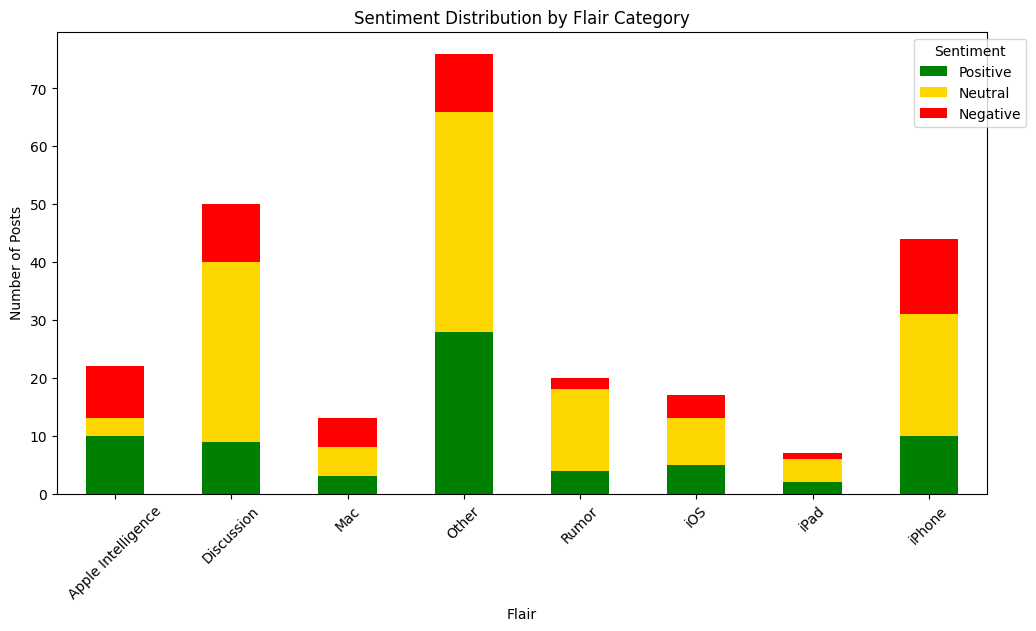

In [27]:
# Plot a stacked bar chart of sentiment per flair 
sentiment_by_flair = top_reddit_posts.groupby(
    ['Flair_Clean', 'Title_Sent']
).size().unstack(fill_value=0)

# Make sure columns appear in a fixed order
sentiment_by_flair = sentiment_by_flair[['Positive', 'Neutral', 'Negative']]

# Colors for each sentiment
sentiment_colors = {
    'Positive': 'green',
    'Neutral': 'gold',
    'Negative': 'red'
}

sentiment_by_flair.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=[sentiment_colors[col] for col in sentiment_by_flair.columns]
)

plt.title('Sentiment Distribution by Flair Category')
plt.xlabel('Flair')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1))
plt.show()

This chart shows how positive, neutral and negative sentiments are distributed across different post flair topics on Apple subreddit.

We can see that Most flairs are dominated by neutral sentiment espcially Other, Discussion, and iPhone. While positive sentiment is strongest among "Apple Intelligence" and "Iphone" wihch generate noticeably more positive posts and give excitemen. On the other hand, negative sentiment is relatively low across all categories but show higher in Apple Inteligence and iPhone. Therefore, it leads to the fact that people still shows both excitment and also worry about the new features as Apple Intelligence still not fully launched 100% yet and also the new iPhone which is flahship of Apple.

### 3.4.3 Relationship Between **Frequent Words** and **Sentiment Analysis**

I now link the frequent word that use in title to sentiment by using dictionary that created earlier. Then count how many of those posts are Positive, Neutral or Negative 

The stacked bar chart shows whether titles that mention words are mostly psotivie, negative or neutral which helps us to understand about how keyword associated with different emotional tones.

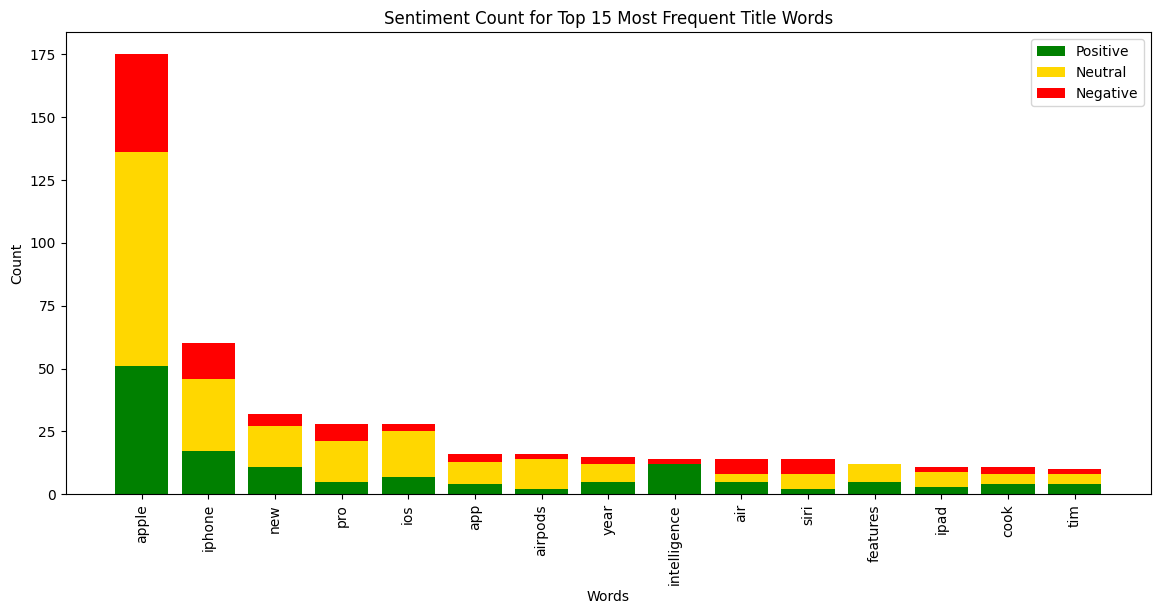

In [28]:
word_to_titles = {}  

#Build mapping
for idx, t in enumerate(title_clean):
    unique_words = set(re.findall(r'\b[a-zA-Z]{3,}\b', t))
    for w in unique_words:
        if w not in stop_words:
            word_to_titles.setdefault(w, []).append(idx)


# Sentiment counting  for each top word
sentiment_counts = {w[0]: {'Positive': 0, 'Negative': 0, 'Neutral': 0} 
                    for w in top_words}

#Count how many positive/neutral/negative titles contain each word 
for word_tuple in top_words:
    word = word_tuple[0]
    rows = word_to_titles[word]  
    for r in rows:
        sent = top_reddit_posts.loc[r, 'Title_Sent']
        sentiment_counts[word][sent] += 1


# Prepare plot data 
labels = [w[0] for w in top_words]
positive = [sentiment_counts[w]['Positive'] for w in labels]
negative = [sentiment_counts[w]['Negative'] for w in labels]
neutral  = [sentiment_counts[w]['Neutral']  for w in labels]


# Plot 
plt.figure(figsize=(14,6))

plt.bar(labels, positive, label='Positive', color='green')
plt.bar(labels, neutral,  bottom=positive, label='Neutral', color='gold')
plt.bar(labels, negative, bottom=[positive[i] + neutral[i] for i in range(len(labels))], 
        label='Negative', color='red')

plt.xticks(rotation=90)
plt.title('Sentiment Count for Top 15 Most Frequent Title Words')
plt.xlabel('Words')
plt.ylabel('Count')
plt.legend()
plt.show()

This stacked bar chart shows how sentiment varies across the most commonly used words in post titles. As **apple** which is the most uses word appears to shows a balanced senitment mix, but with neutral dominate. Word like **"iphone", "pro", "ios" , and "new"** also show neutral sentiment which can lead to intepretation that these are typicaly used in update, and fact post. Positive sentiment is noticeable for words such as **"intelligence" and "year"** which is shows excitement around new features of apple intelligence similar to earlier and excitement toward the annual update such as new software and hardware. Negative sentiment appear but mostly lower overall.

### 3.4.4 Relationship Between **Frequent Bigram** and **Sentiment Analysis**

I repeat the analysis for the top 15 bigram by count how many titles of most used bigram are positive, negative or neutral. 

The result shows as stacked bar chard shows which product phrase attract positive attention and which one appear netural and negative context.

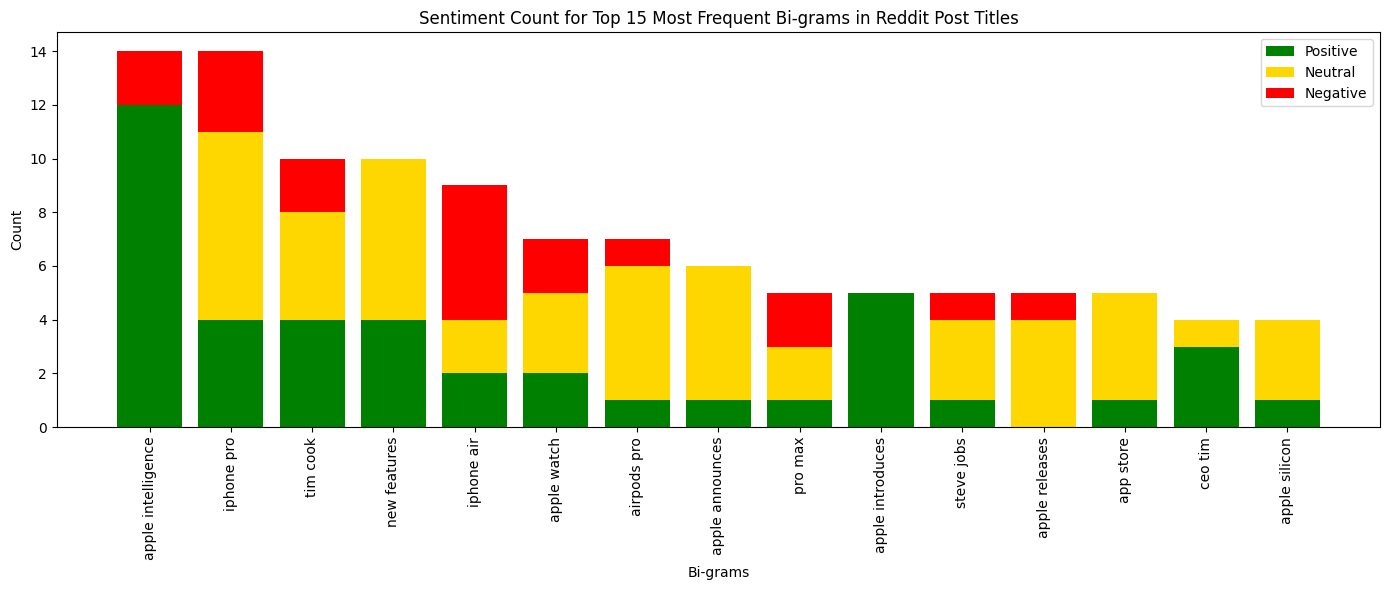

In [29]:
bigram_to_titles = {}
bigram_list = []

#Build mapping 
for idx, t in enumerate(title_clean):
    tokens = re.findall(r'\b[a-zA-Z]{3,}\b', t)
    tokens = [w for w in tokens if w not in stop_words]

    # unique bigrams per title
    bigrams_in_title = set(ngrams(tokens, 2))

    for bg in bigrams_in_title:
        bigram_list.append(bg)
        bigram_to_titles.setdefault(bg, []).append(idx)

bigram_counts = Counter(bigram_list)

top_bigrams = bigram_counts.most_common(15)

# Convert bigrams to readable text labels
bg_labels = [' '.join(bg) for bg, i in top_bigrams]

sentiment_counts_bg = {label: {'Positive': 0, 'Negative': 0, 'Neutral': 0}
                       for label in bg_labels}

# Count sentiment per bi-gram
for bg, i in top_bigrams:
    label = ' '.join(bg)
    rows = bigram_to_titles[bg]

    for r in rows:
        sent = top_reddit_posts.loc[r, 'Title_Sent']
        sentiment_counts_bg[label][sent] += 1

positive = [sentiment_counts_bg[w]['Positive'] for w in bg_labels]
neutral  = [sentiment_counts_bg[w]['Neutral']  for w in bg_labels]
negative = [sentiment_counts_bg[w]['Negative'] for w in bg_labels]


plt.figure(figsize=(14,6))

plt.bar(bg_labels, positive, label='Positive', color='green')
plt.bar(bg_labels, neutral,  bottom=positive, label='Neutral', color='gold')
plt.bar(bg_labels,
        negative,
        bottom=[positive[i] + neutral[i] for i in range(len(bg_labels))],
        label='Negative',
        color='red')

plt.xticks(rotation=90)
plt.title('Sentiment Count for Top 15 Most Frequent Bi-grams in Reddit Post Titles')
plt.xlabel('Bi-grams')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

This chart shows how sentiment varies for the most common bigram (two word phrases) that appear across Reddit titles. Phrases like **“apple intelligence” and “iphone pro”** appear most often and show a high share of positive sentiment, suggesting they are generally discussed favorably by the community similar to earlier. Some bigrams such as **“iphone air” and “apple watch”** show a more mixed distribution, containing noticeable negative and neutral posts, indicating more diverse or controversial discussions. Meanwhile, phrases related to product releases tend to be mostly neutral, reflecting their informational nature. Suprisingly, the bigram of **apple introudce** are show 100% of post are positive sentiment which shows that people excited on apple introduces new announcement or product.

### 3.4.5 Relationship Between **Upvotes** and **Sentimental Analysis**

I link sentiment to engagmenet upvotes by group posts using 'TItle_Sent' and compute the number of posts, mean for each sentiment class. 

The table and chart show whether Positive, Neutral or Negative titles tend to receive more upvotes. 

In [30]:
#Summary table of upvotes by sentiment
sentiment_upvotes = top_reddit_posts.groupby('Title_Sent')['Upvotes'].agg(
    Count='count',
    Mean_Upvotes='mean',
    Median_Upvotes='median',
    Max_Upvotes='max'
)

print(sentiment_upvotes)

            Count  Mean_Upvotes  Median_Upvotes  Max_Upvotes
Title_Sent                                                  
Negative       54   2592.722222          2104.0         9867
Neutral       124   2471.491935          2097.5        13574
Positive       71   2801.323944          2073.0        11258


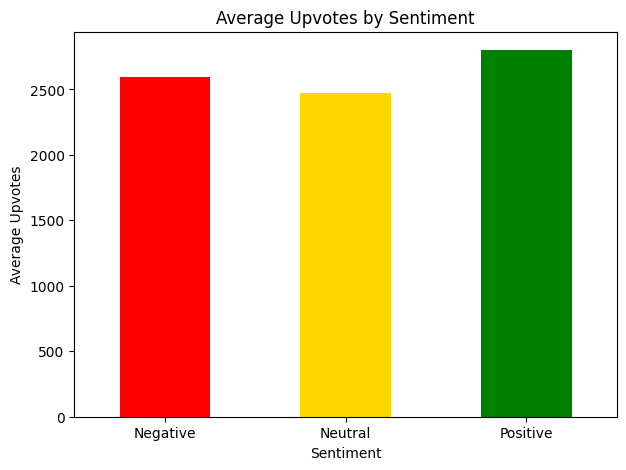

In [31]:
# Bar chart plot of  average upvotes by sentiment 
mean_upvotes = top_reddit_posts.groupby('Title_Sent')['Upvotes'].mean()

plt.figure(figsize=(7,5))
mean_upvotes.plot(kind='bar', color=['red','gold','green'])

plt.title('Average Upvotes by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Upvotes')
plt.xticks(rotation=0)
plt.show()

This bar chat compres the **average number of upvotes** received by posts with Positvie, Neutral, Negative sentiment. 

Positive posts receive the highest engagment with around 2800 upvotes in average which show that Apple news that tends to show optimistic and tend to attract more attention. Meanwhile, Negative posts receive slightly fewer upvotes than positive ones, but still relatively high nearly equat to positive one which shows that critical concerning topics are also attact strong engagment as it may spark discussion. On the other hand, Neutral posts receive the lowest average upvotes with 2450 which shows less emotionally toward facts and neutral post.

## 3.5 Time-Series (UTC)

To understand user behaviour, I extract the posting hour and day of the week from timestamps. These features help reveal when Apple-related posts are most active.

In [32]:
#Extract hour of the day (0-23) and day name from the timestamp

top_reddit_posts['Hour_Post'] = top_reddit_posts['Created_At'].dt.hour
top_reddit_posts['Day_of_Week'] = top_reddit_posts['Created_At'].dt.day_name()


In [33]:
# old_order ['Title', 'Upvotes', 'Flair', 'Flair_Clean', 'Num_Comments', 'Body', 'Created_UTC',
#        'Post_ID', 'Created_At', 'Created_Date', 'Created_Time',
#        'Title_compound', 'Title_Sent', 'Title_Word_Count', 'Body_Word_Count',
#        'Log_Upvotes', 'Log_Num_Comments', 'Log_Body_Word_Count', 'Flair_Clean',
#        'Hour_Post', 'Day_of_Week']


#Reorder columns to group related variable together 

new_order = ['Title', 'Upvotes', 'Log_Upvotes', 'Flair', 'Flair_Clean' ,
      'Num_Comments', 'Log_Num_Comments', 'Body', 'Created_UTC',
      'Post_ID', 'Created_At', 'Created_Date', 'Day_of_Week', 'Created_Time', 'Hour_Post',
      'Title_Word_Count', 'Body_Word_Count', 'Log_Body_Word_Count', 'Title_compound', 'Title_Sent'
        ]

top_reddit_posts = top_reddit_posts[new_order]

### 3.5.1 Post Per Hour of the Day

This plot shpws which hours of the day have the highest posting activity. With Red bars represent posts made before noon and green bars represent post made after noon. 

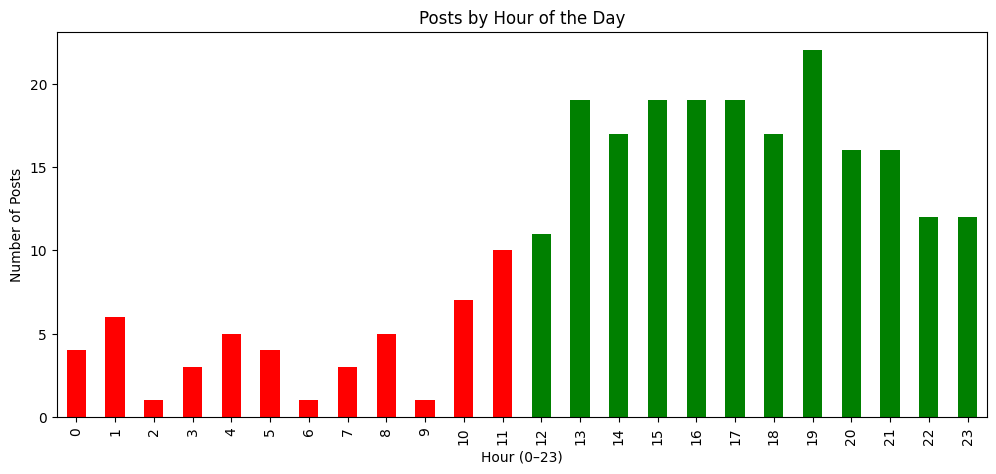

In [34]:
# Count how many posts occur in each hour (0-23)
Posts_Per_Hour = top_reddit_posts['Hour_Post'].value_counts().sort_index()

# Choose color per hour: green for 12-23, red for 0-11
Colors_Hour = [
    'green' if h >= 12 
    else 'red' for h in Posts_Per_Hour.index
]

plt.figure(figsize=(12,5))
Posts_Per_Hour.plot(kind='bar', color= Colors_Hour)
plt.title('Posts by Hour of the Day')
plt.xlabel('Hour (0–23)') #12 AM - 11 PM
plt.ylabel('Number of Posts')
plt.show()

The chart shows that Reddit activity in r/Apple is much lower during **midnight - 11 AM** (red bars) and increases sharply from **12 PM onward,** peaking between **1 PM and 8 PM**(green bars). This pattern indicates that the community is primarliy active during afternoon adn evening hours, possibily due to the global time-zone overlap and as it a time after work or school.

### 3.5.2 Post by Day of the Week

This plot counts how many posts appear on each day of the week. 

The highest bars indicate busy days on the subreddit while shorter bars represent on quiter days. 

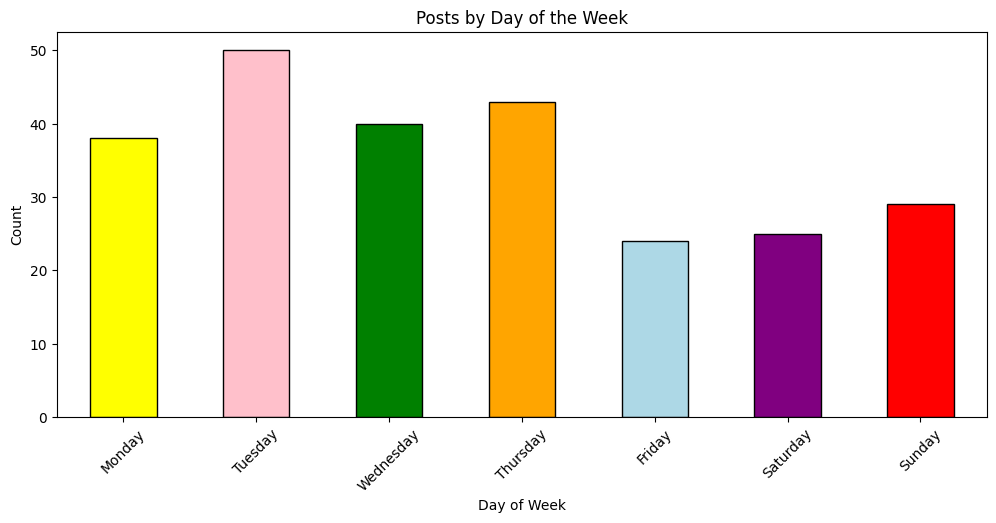

In [35]:
# Count posts per weekday, preserving a logical Monday-Sunday order
Posts_Per_Day_of_Week = top_reddit_posts['Day_of_Week'].value_counts().loc[
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
]

# Create color mapping for Day_of_Weeks
colors_Day_of_Week = ['yellow', 'pink', 'green', 'orange', 'lightblue', 'purple', 'red']

plt.figure(figsize=(12, 5))
Posts_Per_Day_of_Week.plot(kind='bar', color=colors_Day_of_Week, edgecolor='black')

plt.title('Posts by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

This bar chart shows that posting is fairly consisten throughout the week, but on **Tuesday** has the highest number of post, followed by **Thursday and Wedneday**. It also shows that activity drops toward the weekend, with **Friday and Saturday** being the least active days. This suggests users tend to discuss Apple related topics more during weekdays which is possibly reflect that during work week engagement while posting slows down as users transition into weekend.

### 3.5.3 Post over Year

This line chart shows how many top posts appear on each day across the year. 


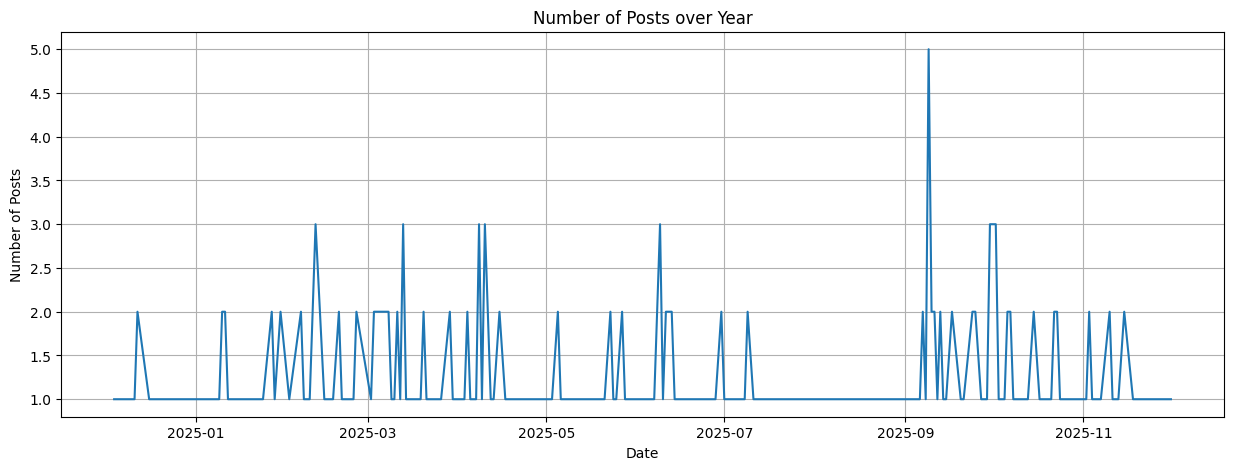

In [36]:
#Daily post counts over time
Posts_Per_Day = top_reddit_posts.groupby('Created_Date').size()

plt.figure(figsize=(15,5))
Posts_Per_Day.plot(kind='line')
plt.title('Number of Posts over Year')
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.grid(True)
plt.show()

This line chart shows how many posts were created on each date. Because we chosen the "Top posts of the year" which only includes **the best performing posts**, the datast contain at most a few posts per day, and sometimes only one. 

We can see a few small spikes day with 3-5 top posts, however, overall the activity is distributed and highly ireegular. As this pattern refelcts **how Reddit filters top posts**


### 3.5.4 Monthly Post by Flair Trend

This graph tracks how diffeerent flair categories evolve over time at the onthly level: 
- Each line corresponds to a flair
- Peaks in line show months where topic was active

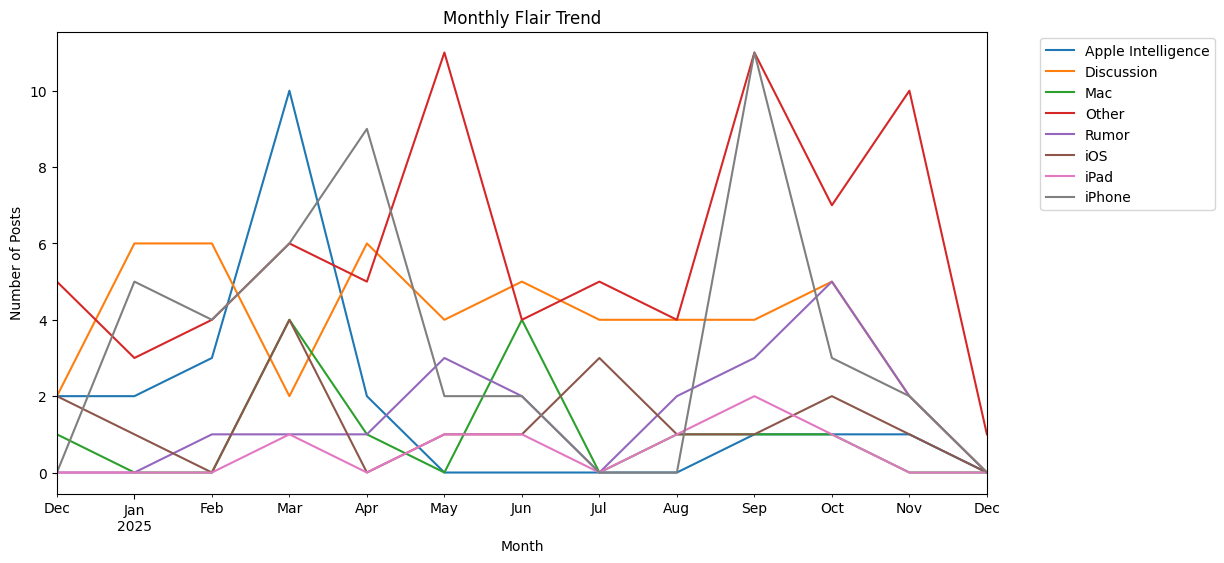

In [37]:
#Convert to month period, then back to timestamp for plotting
top_reddit_posts['Month'] = top_reddit_posts['Created_At'].dt.to_period('M').dt.to_timestamp()

# Count posts per (month, flair_clean) combine
Monthly_Trend = top_reddit_posts.groupby(['Month', 'Flair_Clean']).size().unstack(fill_value=0)


Monthly_Trend.plot(figsize=(12,6))
plt.title('Monthly Flair Trend')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

This line chart illustrate how frequently each flair category appears across different months.

- **Other, Discussion and iPhone** are the most consistently active flairs throughout the year, showing regular appearances almost every month. However, **Other** reaches its highest point in May and September, and **iPhone** jumps sharply in September which allign with the Apple product release cycle during September and October

- **Apple Intelligence** shows a sharp spike in *March* and *April* due to the expand of language, the update regarding Visual Intelligence people have show excitement, and also the lawsuit regarding allegation of false advertising and unfair competition on March 19, 2025 (The Hindu, 2025). And also the spike up during *September* and *October* which is between the OS update that also update Apple Intelligence software (Apple Newsroom, 2025).
  
- **Mac, iOS, iPad, and Rumor** have lower but irregular activity, the appearing only in certain months.

### 3.5.5 Upvotes over Year

This scatter plot shows each post as a point with:
- x-axis = posting date
- y axis = number of upvotes

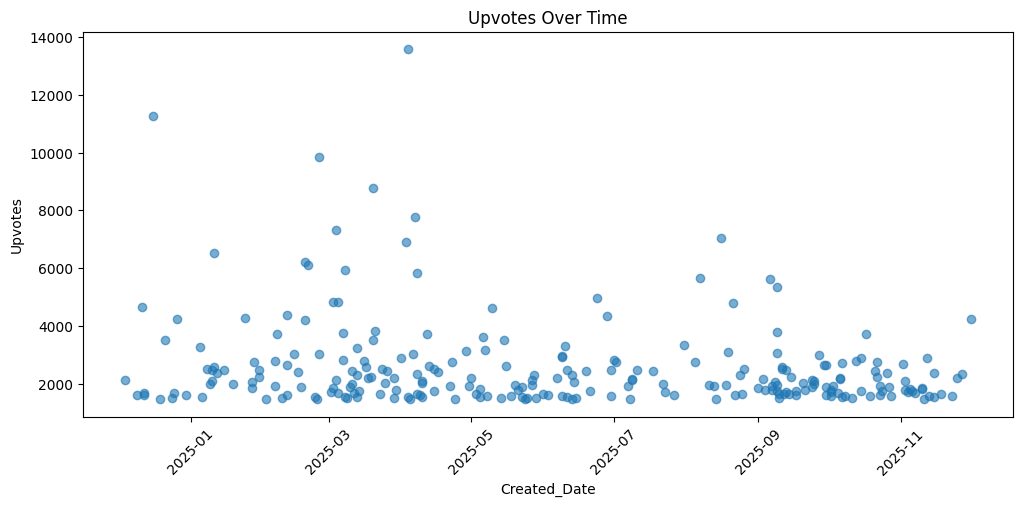

In [38]:
plt.figure(figsize=(12,5))
plt.scatter(
    top_reddit_posts['Created_Date'], 
    top_reddit_posts['Upvotes'], 
    alpha=0.6
)
plt.title('Upvotes Over Time')
plt.xlabel('Created_Date')
plt.ylabel('Upvotes')
plt.xticks(rotation=45)
plt.show()

The scatter plot visualizes how Reddit post upvotes fluctuated throughout the year. Each point represents one post, positioned by its posting date on x-axis and its upvote on the y-axis.

Overall, the distribution is **highly scattered** which show that upvote performance does not follow a clear time-based trend. Most posts receive between **1,500 - 3,500 upvotes**, but there are notable outliers reaching **7,000 - 13,000 upvotes** which shows occasional viral posts. These spikes appear at vaiour months and do not cluster around any specific particular period which suggest that **high engagment is driven more by content topic rather than seasonal timing**

### 3.5.6 Average Sentimental over Year

Average the VADER Title_compound score for all posts on each date and plot
- Values above 0 shoes title are on average as more positive that day
- Values below - indicates more negative tone 

This line plot shows the daily average sentiment score of post titles. As it will show do users become more positive or negative around certain months, or are launch period associated with positive or negative reaction more.

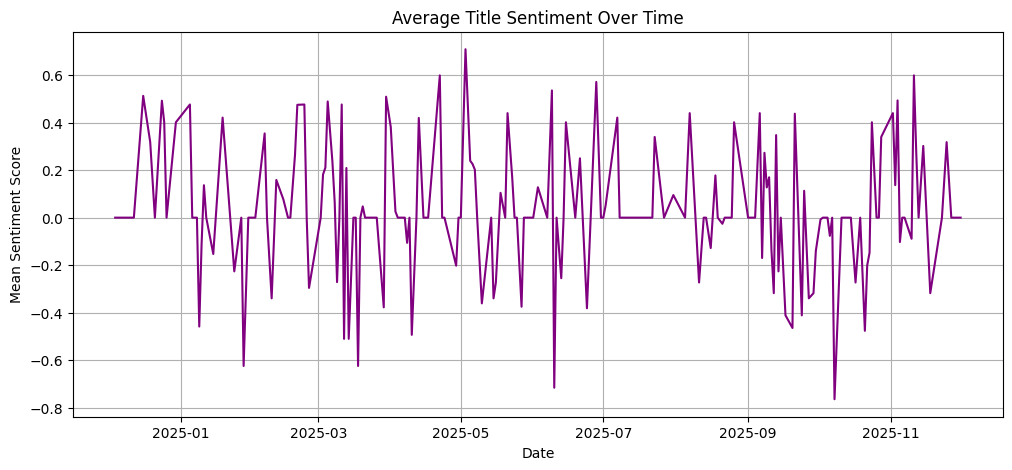

In [39]:
Sentiment_Over_Time = top_reddit_posts.groupby('Created_Date')['Title_compound'].mean()

plt.figure(figsize=(12,5))
Sentiment_Over_Time.plot(kind='line', color='purple')
plt.title('Average Title Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Sentiment Score')
plt.grid(True)
plt.show()

This line chart shows **how the average VADER compound sentiment of Reddit post titles change day to day across the year**. We can see that **sentiment fluctuates** from day to day ranging between **-0.7 *negative) and +0.7 (positive)**. Moreover, the line frequently crosses **0** which shows that **positive and negative posts appear throughout the year** with no long-lasting trend in either direction. It also suggests that reaction to Apple community news are **event driven** rather than consistent trends as it has some **short bursts of positive or negative sentiment** but quickly return to neutral. This also show that as the variation high **daily sentiment alone is not a strong predictor of long term mood of this community**

# Step 4 : Ask a question about your data 

## **4.1 Does the mood tone of a Reddit post (from Sentimental Analysis) influence to the engagement (Upvotes & Comments)?**

This section explores whether emotional tone of Reddit tiles affects how users interact with posts or not.
Engagment is measured using **Upvotes and Number of Comments**

In [40]:
import seaborn as sea

### 4.1.1 Do positive posts receive more upvotes than negative or neutral mood posts? 

We start by comparing the group means of upvotes across sentiment categories

In [41]:
#Calculate the mean upvotes for each sentiment class
group_means = top_reddit_posts.groupby("Title_Sent")[["Upvotes"]].mean()
print(group_means)

                Upvotes
Title_Sent             
Negative    2592.722222
Neutral     2471.491935
Positive    2801.323944


/var/folders/rk/vrfbphk975xfx3m0npm7jyww0000gn/T/ipykernel_32823/2492363862.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.boxplot(data= top_reddit_posts, x="Title_Sent", y="Upvotes", palette=["green","gold","red"])


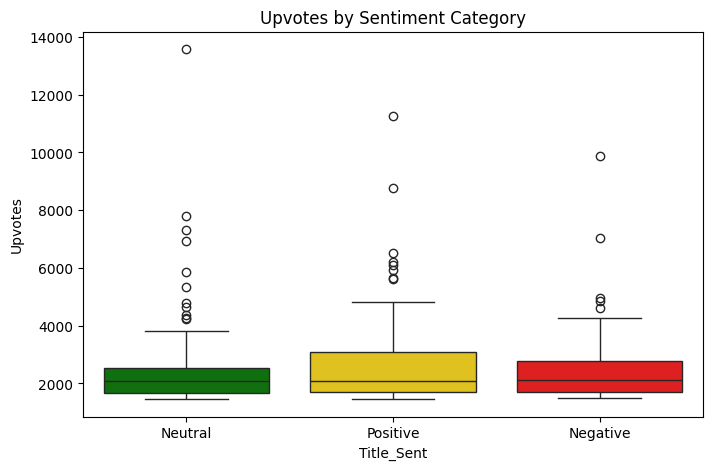

In [42]:
plt.figure(figsize=(8,5))
sea.boxplot(data= top_reddit_posts, x="Title_Sent", y="Upvotes", palette=["green","gold","red"])
plt.title("Upvotes by Sentiment Category")
plt.show()

Test for difference in means between each group whether engagement (Upvotes/Comments) differed across sentiment categories (Positive, Nuetral, Negative) by using **Kruskai-Wallis**. 

**Kruskai-Wallis H-Test** is non-parametric test due to the engagement variables were highly skewed with outliers, which is violates the ANOVA assumption (that need to be normal distrbution). 

**Hypthesis Testing**
Null hypothesis (H0) is that population means are equal  
Alteranative hypothesis (H1) is that population mean are differ

In [43]:
from scipy.stats import kruskal

In [44]:
# Split data into groups
pos_upvotes = top_reddit_posts[top_reddit_posts['Title_Sent'] == 'Positive']['Upvotes']
neu_upvotes   = top_reddit_posts[top_reddit_posts['Title_Sent'] == 'Neutral']['Upvotes']
neg_upvotes  = top_reddit_posts[top_reddit_posts['Title_Sent'] == 'Negative']['Upvotes']

# Kruskal-Wallis test
h_stat, p = kruskal(pos_upvotes, neu_upvotes, neg_upvotes)


print("p-value =", p)


# If the p-value lower than 0.05 its reject null hypotheiss if not then fail to reject
if p <= 0.05: 
    print("Reject the null hypothesis: There is a significant between groups")
else:  
    print("Fail to reject null hypthesis: " \
    "There is NO statistically significant different between the groups")




p-value = 0.5767653486133704
Fail to reject null hypthesis: There is NO statistically significant different between the groups


Since p-value is 0.445 (> 0.05), we **fail to reject the null hypothesis**. This mean **there is no statistically significant difference in upvote levels across the three sentiment categories**. Although Positive posts seem to have slightly higher average upvotes, this difference is not strong enough stastically to conclude that sentiment actually that sentiment actually influence engagement. This means sentiment did not guarantee more or less upvotes.

### 4.1.2 Does sentiment affect how many comments a post receives?

Next we test whether sentiment influences the **number of comments** a post receives. Like upvotes, coments counts are skewed and contain extreme values, so Kruskal- Wallis is again the correct method.

In [45]:
num_comments_means = top_reddit_posts.groupby("Title_Sent")[["Num_Comments" ]].mean()
print(num_comments_means)

            Num_Comments
Title_Sent              
Negative      440.537037
Neutral       438.370968
Positive      576.169014


/var/folders/rk/vrfbphk975xfx3m0npm7jyww0000gn/T/ipykernel_32823/3590035566.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.boxplot(data=top_reddit_posts, x="Title_Sent", y="Num_Comments", palette=["green","gold","red"])


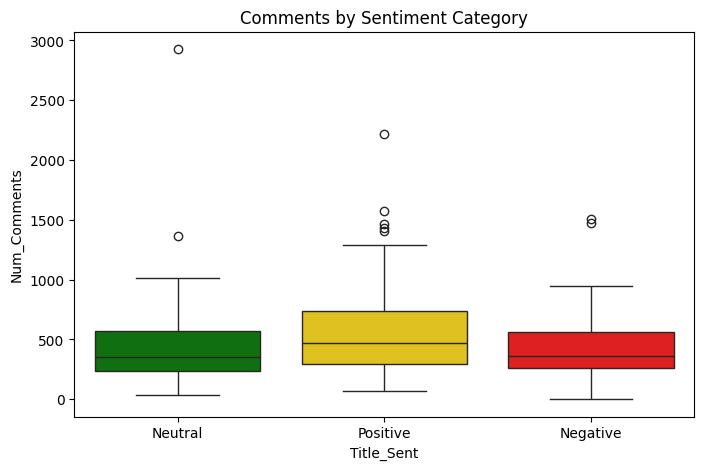

In [46]:
plt.figure(figsize=(8,5))
sea.boxplot(data=top_reddit_posts, x="Title_Sent", y="Num_Comments", palette=["green","gold","red"])
plt.title("Comments by Sentiment Category")
plt.show()

In [47]:
pos_comments = top_reddit_posts[top_reddit_posts["Title_Sent"] == "Positive"]["Num_Comments"]
neu_comments = top_reddit_posts[top_reddit_posts["Title_Sent"] == "Neutral"]["Num_Comments"]
neg_comments = top_reddit_posts[top_reddit_posts["Title_Sent"] == "Negative"]["Num_Comments"]

h_stat, p = kruskal(pos_comments, neu_comments, neg_comments)


print("p-value =", p)

if p <= 0.05: 
    print("Reject the null hypothesis: There is a significant between groups")
else:  
    print("Fail to reject null hypthesis: " \
    "There is NO statistically significant different between the groups")



p-value = 0.03399547913889907
Reject the null hypothesis: There is a significant between groups


P-value is 0.02352 which mean we **reject the null hypothesis**. This suggest that there **is a statiscally significant difference** in comment counts across the sentiment categories, which shows that user discussion levels or comments **depend on the emotional tone of the post**. Unlike, upvotes which showed **no meaningful difference** the number of comments does vary by sentiment.

### 4.1.3 Is compound sentiment correlated with engagement?

In this section, I investigate whether the strength of emotional tone is associated with how much engagement a post receives on Reddit.

Measure Correlation by using **Spearman** correlation cofficients as each method captures a different type of relationship.  Spearman correlation is a non-parametric test that does not require normality and is more suitable to skewed data and outliers which are present in Number of Comments and Upvotes Distribution. In short, **Spearman** measures whether higher sentiment scores tend to be associated with higher engagment or not (Upvotes and Number of Comments)

Due to the upvotes and number of comments that are extremely skewed, using **Log_Transformation** (from 2.2.2) make it stabilise variance and make data suitable for correlation analysis. 

In [48]:
from scipy.stats import spearmanr

corr_up, p_up = spearmanr(top_reddit_posts['Title_compound'], 
                          top_reddit_posts['Log_Upvotes']) 
        # corr_up --> Spearman correlation coefficiant, p_up --> p-value 

corr_com, p_com = spearmanr(top_reddit_posts['Title_compound'], 
                            top_reddit_posts['Log_Num_Comments'])

print("Sentiment vs Upvotes:", corr_up, p_up)
print("Sentiment vs Comments:", corr_com, p_com)

Sentiment vs Upvotes: 0.01754368092767752 0.7829606515772408
Sentiment vs Comments: 0.1367931467766168 0.03093934916690756


1. Sentiment vs Upvotes
Spearman ρ ≈ 0.019, p ≈ 0.765, this is effectively zero correlation. This shows that **Sentiment does not predict how many upvotes a post receives.**

2. Sentiment vs Number of Comments
Spearman ρ ≈ 0.138, p ≈ 0.0297, this shows a **weak positive correlation** but significant. Posts with **slightly more positive sentiment** tend to receive more comments, although the effect is weak. 

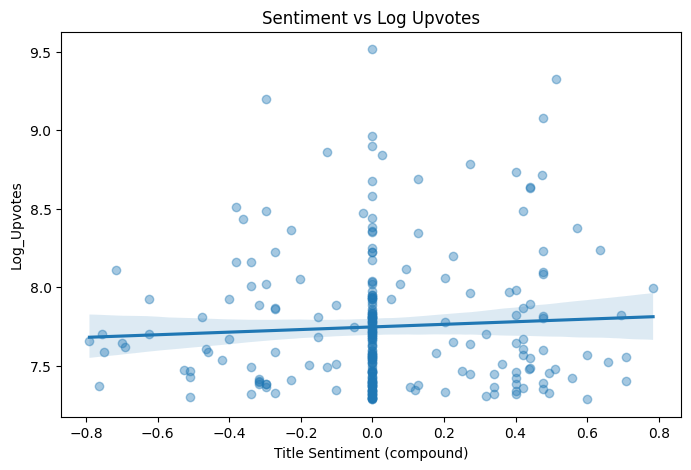

In [49]:
plt.figure(figsize=(8,5))
sea.regplot(x='Title_compound', y='Log_Upvotes', data=top_reddit_posts,
            scatter_kws={'alpha':0.4})
plt.title("Sentiment vs Log Upvotes")
plt.xlabel("Title Sentiment (compound)")
plt.ylabel("Log_Upvotes")
plt.show()


- The regression line is almost flat
- Data appear randomly scattered
- There is no clear upward and downward pattern

Therefore, its confirm that sentiment does not influence upvotes

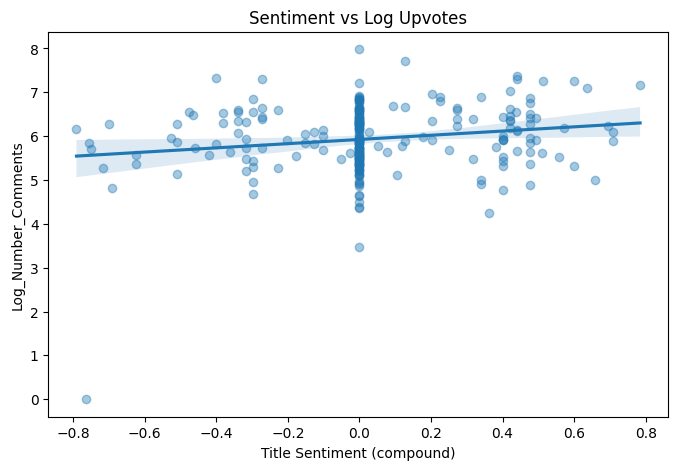

In [50]:
plt.figure(figsize=(8,5))
sea.regplot(x='Title_compound', y='Log_Num_Comments', data=top_reddit_posts,
            scatter_kws={'alpha':0.4})
plt.title("Sentiment vs Log Upvotes")
plt.xlabel("Title Sentiment (compound)")
plt.ylabel("Log_Number_Comments")
plt.show()


- Slight upward trend in the regression line
- Very scattered but the slope is more visible

Therefore, it supports weak but statistically significant correlation with number of comment

### 4.1.4 Does sentiment remain significant afteer controlling for other factors?

As we explore sentiment and engagment using Kruskal-Wallis for group comparisons, Spearman for Correlation, however, **sentiment stll appear weak or noisy because engagement is affected by several variables at the same time** Using multiple linear regression help us understand whether **sentiment independently predicts engagement**

A regression model allow us to check:
1. Whether sentiment still has explanatory power after adjusting for other factors
2. How much each predictor contributes to explain variation in upvotes
3. Whether the relationship is statistically significant or not by using p-value

In [51]:
top_reddit_posts['Log_Upvotes'] = np.log1p(top_reddit_posts['Upvotes'])

In [52]:
%pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


We use Log_Upvotes as the target variable because upvotes are highly skewed as it make model more stable.

Variable included: 

1. Title_compound: Main interest
2. Title_Word_Count: Longer title may influence
3. Log_Num_Comments: High comment volume usually occurs with high engagmenet

In [53]:
import statsmodels.api as sm
import pandas as pd

df = top_reddit_posts.copy()

# Select features
X = df[['Title_compound', 'Title_Word_Count', 'Log_Num_Comments']]
X = sm.add_constant(X)

y = df['Log_Upvotes']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Log_Upvotes   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     13.82
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           2.35e-08
Time:                        03:23:06   Log-Likelihood:                -119.27
No. Observations:                 249   AIC:                             246.5
Df Residuals:                     245   BIC:                             260.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.3934      0.215  

Dependant Variable: 
- Log_Upvotes (log-transformed to reduce skewness)

Independant Variable:
- Title_compound: sentiment score
- Title_Word_Count: length of title
- Log_Num_Comments: engagement level

Siginifcant of Predictors:

1. Title_compound 
   - Coefficient: -.0.0304
   - p-value: 0.730
   - Sentiment has **no meaningful effect** on upvotes similar to earilier that has low correlation

2. Title_Word_Count
   - Coefficient: 0.0080
   - p-value: 0.072
   - Longer titles seem to show a **weak positive impac**t with upvotes but stil not significant enough

3. Log_Num_Comments
   - Coefficient: 0.2126
   - p-value: < 0.001
   - Posts with more comments tend to receive **more upvotes**, which is make sense because discussion drive visibility in social media platform.

R-squared = 0.148 
This shows that the model explains **14.8%** of variation in upvotes, which is understandable and reasonable for social media platform which is chaotic and influence by many external factors

Overall, the regression results show that sentiment does not significantly predict upvotes onces other engagment factors are controlled for (p=0.730). The only significant predictor of upvotes is Log_Num_Comments, meaing posts that have more conversation receive more upvotes regardless of emotional tone. Title length shows a weak effect. These findings suggest that engagmeent behaviour on Apple community is driven more on topic popularity rather than sentiment.

# Step 5: Summarise 

## 5.1 Summary

This project analyzed 250 top posts from the r/Apple subreddit over one year to examine relationship between sentiment, flair topics, and user engagmene. 

Posting Behaviour:
- Posting volume differ by hour and days, with user activity peeking in the afternoon and evening while dropping sharply in early morning hours
- By monthly, the posting patterns showed event drive spikes especially when new software or products launches

Flair:
- "Apple Intelligence", "Discussion", "iPhone" generated the highest average upvotes
- "iPhone" posts received the highest average number of comments, showing they attract more conversation

Text and Sentiments:
- Most titles were Neutral with fewer Positive and Negative posts
- The most frequent words and bigrams is Apple Intelligence, iPhone/iPhone Pro.

Sentiment and Engagement (Upvotes & Comments)

- Kruskai-Wallis tests:
  - Upvotes: No significant difference across sentiment groups which shows that sentiment does not impact upvote count
  - Comments: A significant differences which shows that sentiment does influence comment activity.
  
- Spearman correlation: 
  - Sentiment had no correlation with upvotes
  - Sentiment had small positive correlation with number of comments
  
- Regression Analysis
  - When controlling for title length and number of comments, sentiment remained statistically insignificant in predicting upvotes
  - Log number of Comments was the only strong predictor of upvotes
  - The model suggest very low R-squared which show engagement is influenced by other factors not just only title sentiment.


## 5.2 What we learned

Overall, this analysis shows that 
1. Sentiment does not meaningfully influence by upvotes, however, posts with stronger emotional tone receive more comments.
2. Title sentiment fluctuates over time but does not show a strong trend which shows discussion tone remain mixted
3. Text Features such as word frequency and title length reveal strong patterns on what the Apple community users talk about most

## 5.3 Ideas for Future Work

The project can be extended by more datasets and more advanced methods:

1. More Metadata such as 
   - User information (eg. age, karma of users)
   - Award count

2. Compare with multiple subreddits community
Compare and examine how engagement or sentiment differ across other subreddit that are similar such as: 
   - r/Samsung
   - r/iPhone
   - r/technology
  
3. Use machine learning to train predictive models
   - Random Forest
   - Gradient Boosting

4. Combine with External Data

5. Investigate User Behaviour Patterns 
